# Univariate Exploratory Data Analysis (EDA)

This notebook contains the **Univariate Analysis** on the processed datasets (`master_orders.csv` and `customer_features.csv`).
The objective is to examine the distributions, proportions, and statistics of key variables individually to identify anomalies, skewness, and patterns.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set plotting style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)

# Ensure figures folder exists
os.makedirs('../report/figures', exist_ok=True)


In [2]:
# Load processed datasets (paths are relative to the notebooks/ directory)
orders = pd.read_csv('../data/processed/master_orders.csv')
customers = pd.read_csv('../data/processed/customer_features.csv')

# Convert dates to datetime
orders['order_date'] = pd.to_datetime(orders['order_date'])
customers['latest_order_date'] = pd.to_datetime(customers['latest_order_date'])
customers['signup_date'] = pd.to_datetime(customers['signup_date'])

print(f"Loaded master orders: {orders.shape}")
print(f"Loaded customer features: {customers.shape}")


Loaded master orders: (73022, 30)
Loaded customer features: (5000, 27)


## 1. Distribution of Order-Level Quantitative Variables
We analyze `order_value_usd` (spend per transaction) and `items_count` (items per order).


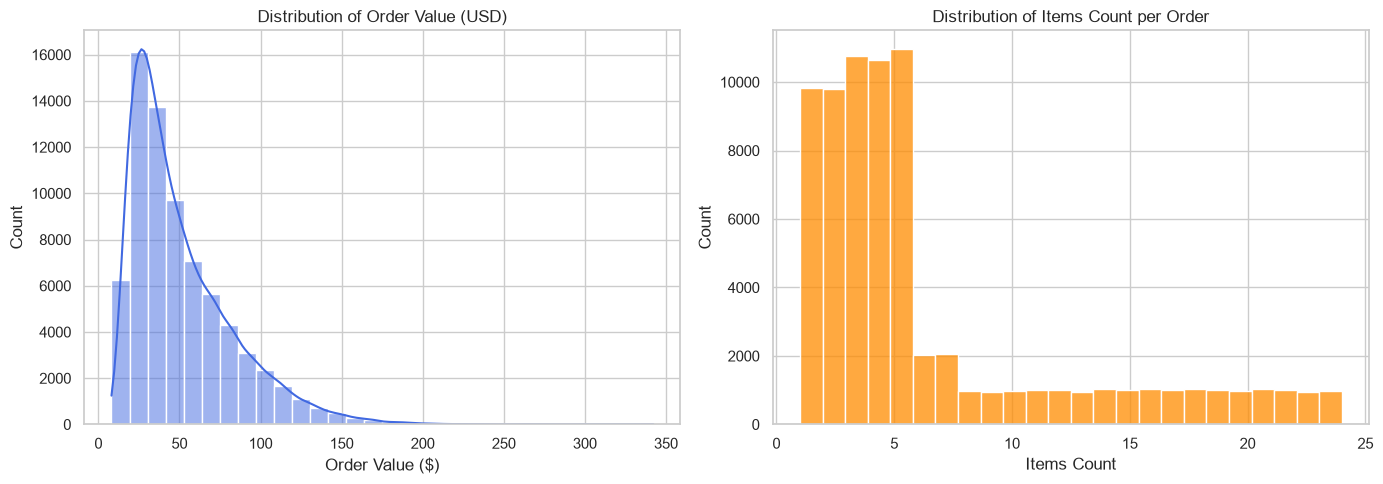

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Order Value distribution
sns.histplot(orders['order_value_usd'], bins=30, kde=True, ax=axes[0], color='royalblue')
axes[0].set_title('Distribution of Order Value (USD)')
axes[0].set_xlabel('Order Value ($)')

# Items count distribution
sns.histplot(orders['items_count'], bins=24, kde=False, ax=axes[1], color='darkorange')
axes[1].set_title('Distribution of Items Count per Order')
axes[1].set_xlabel('Items Count')

plt.tight_layout()
plt.savefig('../report/figures/01_order_value_items_dist.png', dpi=300)
plt.show()


## 2. Distribution of Service Metrics (Delays & Ratings)
We examine customer ratings (categorical satisfaction) and delays (operational performance).


/var/folders/sl/47y1_b4n2mgg2sd9h16kxdxm0000gn/T/ipykernel_35132/3018178016.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='customer_rating', data=orders, ax=axes[1], palette='crest')


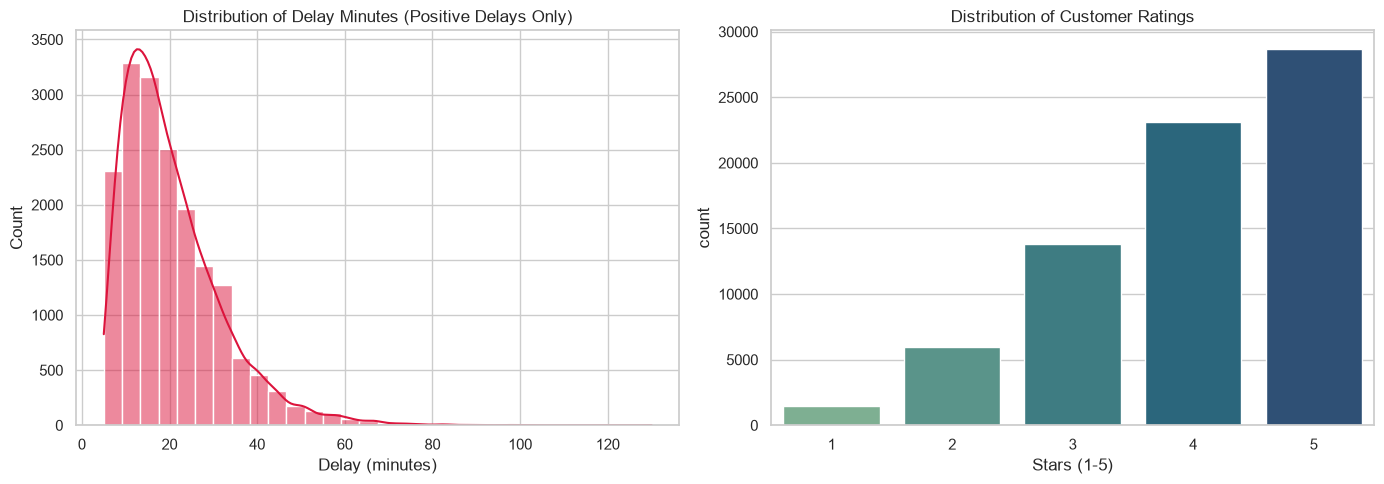

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Delays (Positive delays only for clarity)
positive_delays = orders[orders['delay_minutes'] > 0]['delay_minutes']
sns.histplot(positive_delays, bins=30, kde=True, ax=axes[0], color='crimson')
axes[0].set_title('Distribution of Delay Minutes (Positive Delays Only)')
axes[0].set_xlabel('Delay (minutes)')

# Customer Rating Count
sns.countplot(x='customer_rating', data=orders, ax=axes[1], palette='crest')
axes[1].set_title('Distribution of Customer Ratings')
axes[1].set_xlabel('Stars (1-5)')

plt.tight_layout()
plt.savefig('../report/figures/02_delay_rating_dist.png', dpi=300)
plt.show()


## 3. Proportions of Categorical Transaction Variables
We evaluate the split of vendor categories, delivery types (scheduled/express/on-demand), and promotion usage.


/var/folders/sl/47y1_b4n2mgg2sd9h16kxdxm0000gn/T/ipykernel_35132/36343356.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='vendor_category', data=orders, ax=axes[0], order=orders['vendor_category'].value_counts().index, palette='Set2')
/var/folders/sl/47y1_b4n2mgg2sd9h16kxdxm0000gn/T/ipykernel_35132/36343356.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='delivery_type', data=orders, ax=axes[1], palette='pastel')
/var/folders/sl/47y1_b4n2mgg2sd9h16kxdxm0000gn/T/ipykernel_35132/36343356.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



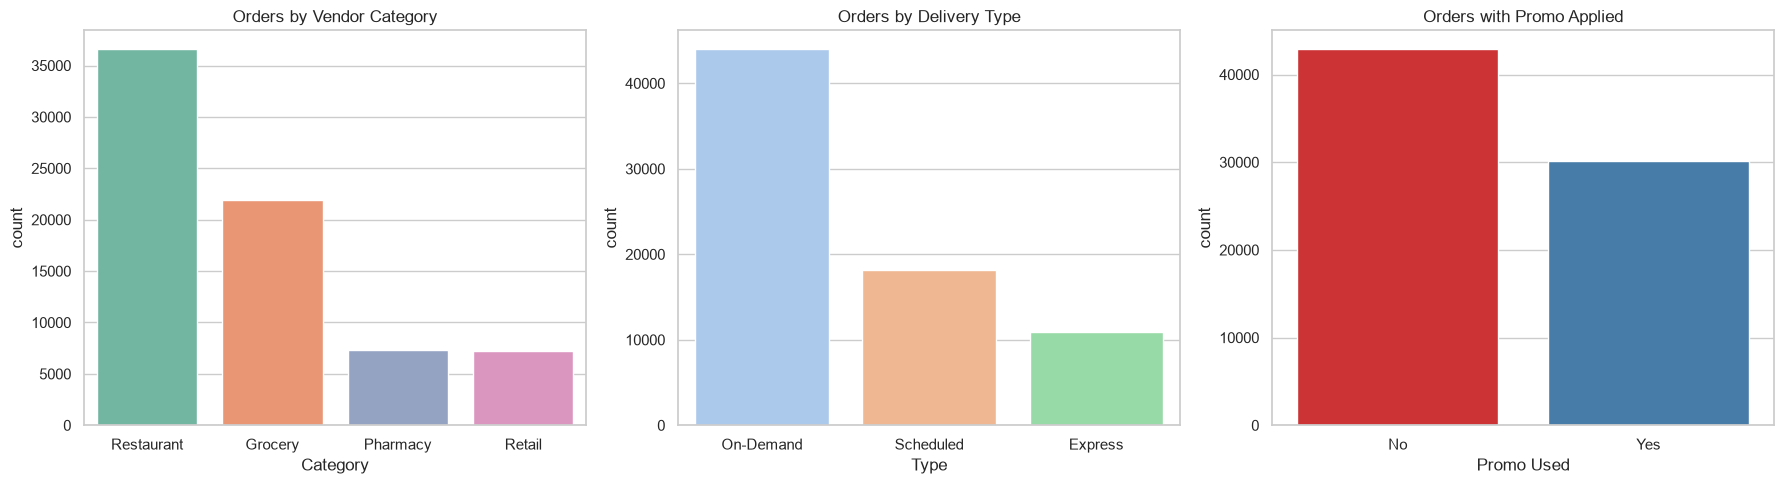

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Vendor Category
sns.countplot(x='vendor_category', data=orders, ax=axes[0], order=orders['vendor_category'].value_counts().index, palette='Set2')
axes[0].set_title('Orders by Vendor Category')
axes[0].set_xlabel('Category')

# Delivery Type
sns.countplot(x='delivery_type', data=orders, ax=axes[1], palette='pastel')
axes[1].set_title('Orders by Delivery Type')
axes[1].set_xlabel('Type')

# Promo Used
sns.countplot(x='promo_used', data=orders, ax=axes[2], palette='Set1')
axes[2].set_title('Orders with Promo Applied')
axes[2].set_xlabel('Promo Used')

plt.tight_layout()
plt.savefig('../report/figures/03_orders_categorical_dist.png', dpi=300)
plt.show()


## 4. Distribution of Customer-Level Engagement Metrics
We evaluate user-level order frequency (total orders), total spend, and their active lifespan in days.


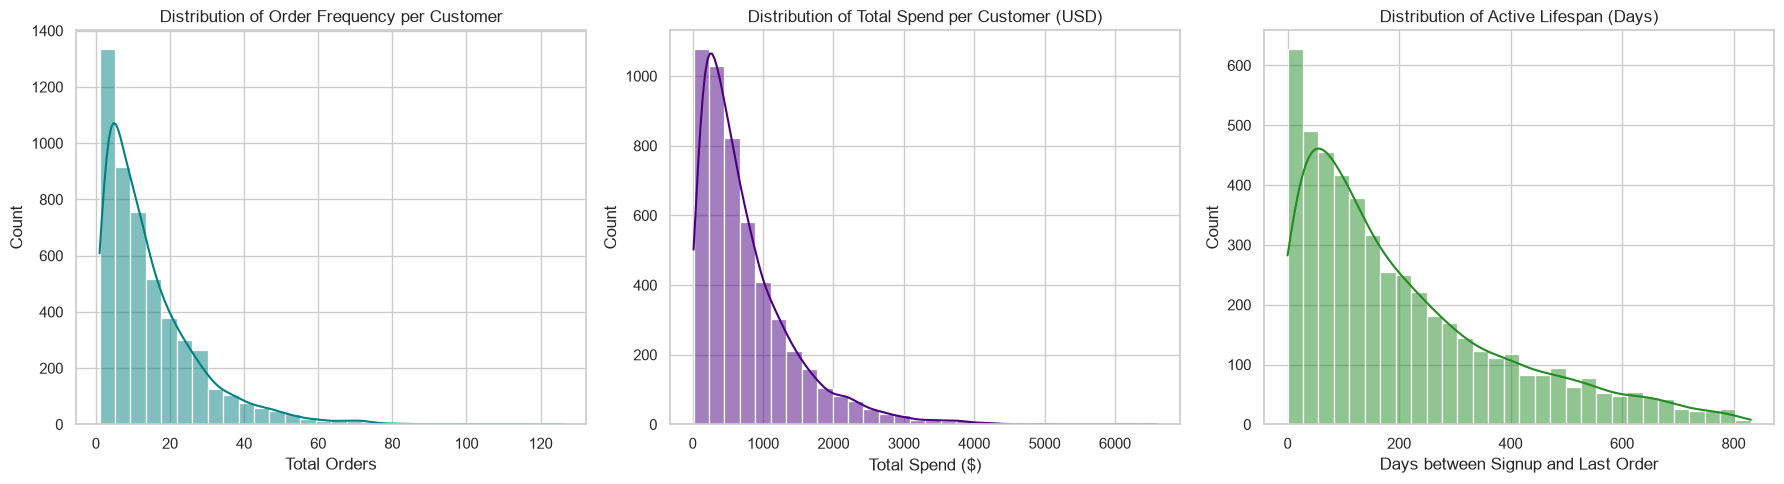

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Order Frequency (Total Orders per Customer)
sns.histplot(customers['frequency'], bins=30, kde=True, ax=axes[0], color='teal')
axes[0].set_title('Distribution of Order Frequency per Customer')
axes[0].set_xlabel('Total Orders')

# Total spend per customer
sns.histplot(customers['total_spend'], bins=30, kde=True, ax=axes[1], color='indigo')
axes[1].set_title('Distribution of Total Spend per Customer (USD)')
axes[1].set_xlabel('Total Spend ($)')

# Active Lifespan (Days between signup and last order)
sns.histplot(customers['active_lifespan_days'], bins=30, kde=True, ax=axes[2], color='forestgreen')
axes[2].set_title('Distribution of Active Lifespan (Days)')
axes[2].set_xlabel('Days between Signup and Last Order')

plt.tight_layout()
plt.savefig('../report/figures/04_customer_engagement_dist.png', dpi=300)
plt.show()


## 5. Proportions of Demographics, Segments, and Churn
We analyze the customer segmentation split, device preferences, and the behavioral churn rate.


/var/folders/sl/47y1_b4n2mgg2sd9h16kxdxm0000gn/T/ipykernel_35132/736438727.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='is_churned', data=customers, ax=axes[0], palette='vlag')
/var/folders/sl/47y1_b4n2mgg2sd9h16kxdxm0000gn/T/ipykernel_35132/736438727.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(['Active (<=90d)', 'Churned (>90d)'])
/var/folders/sl/47y1_b4n2mgg2sd9h16kxdxm0000gn/T/ipykernel_35132/736438727.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='customer_segment', data=customers, ax=axes[1], palette='rocket')
/v

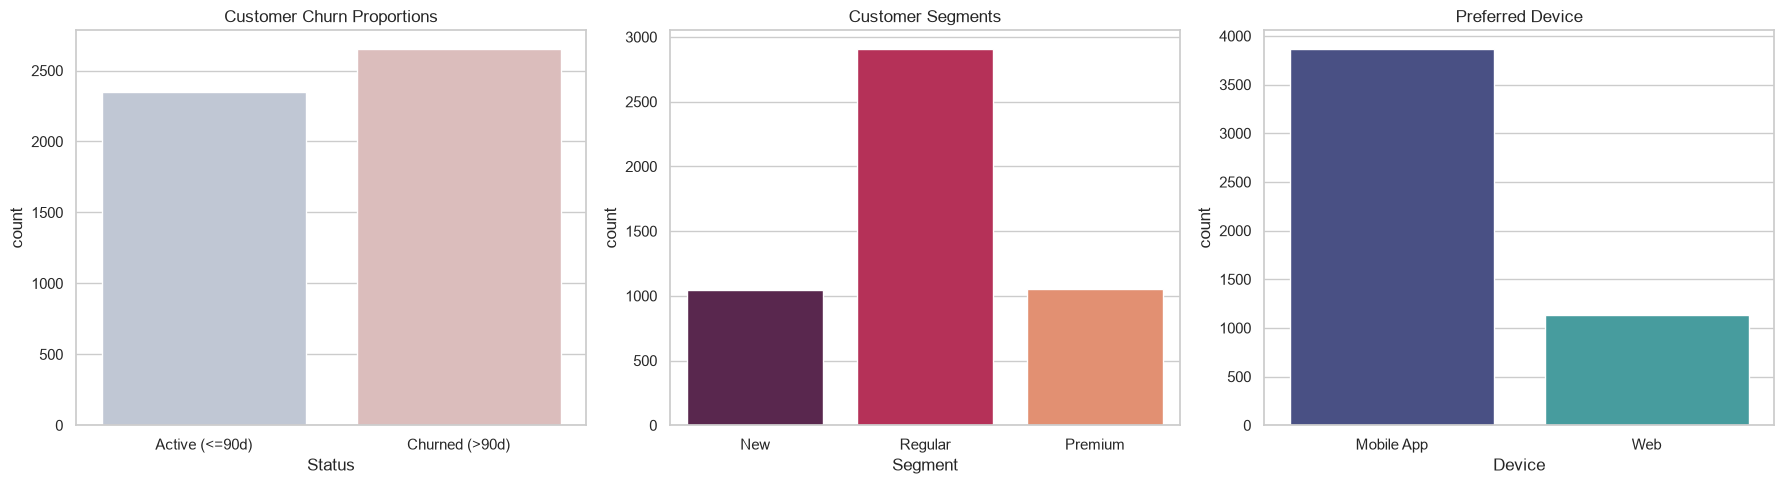

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Churn Split (Inactivity > 90 days)
sns.countplot(x='is_churned', data=customers, ax=axes[0], palette='vlag')
axes[0].set_title('Customer Churn Proportions')
axes[0].set_xticklabels(['Active (<=90d)', 'Churned (>90d)'])
axes[0].set_xlabel('Status')

# Customer Segment
sns.countplot(x='customer_segment', data=customers, ax=axes[1], palette='rocket')
axes[1].set_title('Customer Segments')
axes[1].set_xlabel('Segment')

# Preferred Device
sns.countplot(x='preferred_device', data=customers, ax=axes[2], palette='mako')
axes[2].set_title('Preferred Device')
axes[2].set_xlabel('Device')

plt.tight_layout()
plt.savefig('../report/figures/05_customer_segments_churn.png', dpi=300)
plt.show()
